1. Load the 'Mall Customers' dataset (or any small customer dataset) and apply the DBSCAN algorithm using scikit-learn to cluster users based on their annual income and spending score. Print the number of clusters found and the number of noise points detected.


In [1]:
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("Mall_Customers.csv")

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(eps=0.5, min_samples=5)

labels = dbscan.fit_predict(X_scaled)

df["Cluster"] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

noise = list(labels).count(-1)

print("Number of Clusters:", n_clusters)
print("Noise Points:", noise)

Number of Clusters: 4
Noise Points: 18


2. Visualize the DBSCAN clustering results from your previous task using matplotlib — plot each cluster in a different color, and mark noise points in black. Add axis labels and a legend for clarity.


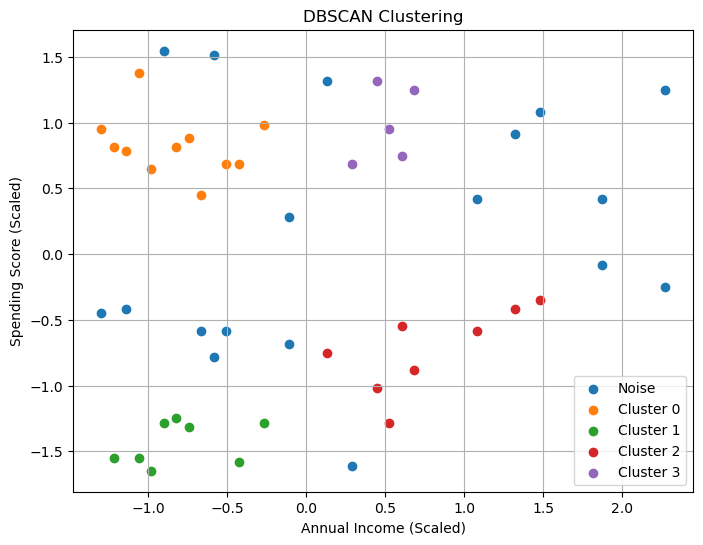

In [2]:
import matplotlib.pyplot as plt
import numpy as np

unique_labels = np.unique(labels)

plt.figure(figsize=(8,6))

for label in unique_labels:

    if label == -1:
        color = "black"
        name = "Noise"
    else:
        color = None
        name = f"Cluster {label}"

    plt.scatter(
        X_scaled[labels == label, 0],
        X_scaled[labels == label, 1],
        label=name
    )

plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.title("DBSCAN Clustering")
plt.legend()
plt.grid(True)

plt.show()

3. Change the DBSCAN parameters (eps and min_samples) to see how the number of clusters and noise points change. Write a short summary (3-4 lines) explaining how parameter choices affect the clustering outcome for your dataset.<br><br><em><strong>Hint:</strong> Try at least two different values for eps and min_samples, and compare results.</em>


In [3]:
parameters = [

    (0.3,5),

    (0.5,5),

    (0.8,5),

    (0.5,10)

]

for eps, min_samples in parameters:

    model = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )

    labels = model.fit_predict(X_scaled)

    clusters = len(set(labels)) - (1 if -1 in labels else 0)

    noise = list(labels).count(-1)

    print("----------------------")
    print("eps =", eps)
    print("min_samples =", min_samples)
    print("Clusters =", clusters)
    print("Noise =", noise)

----------------------
eps = 0.3
min_samples = 5
Clusters = 0
Noise = 50
----------------------
eps = 0.5
min_samples = 5
Clusters = 4
Noise = 18
----------------------
eps = 0.8
min_samples = 5
Clusters = 1
Noise = 1
----------------------
eps = 0.5
min_samples = 10
Clusters = 0
Noise = 50


4. Compare DBSCAN and K-Means on the same dataset: run both algorithms, plot their cluster assignments side by side, and briefly note which method better handles outliers or oddly-shaped clusters.<br><br><em><strong>Constraint:</strong> Use the same features and number of clusters (for K-Means) as you observed with DBSCAN.</em>


c:\Users\RAJEET\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1411: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


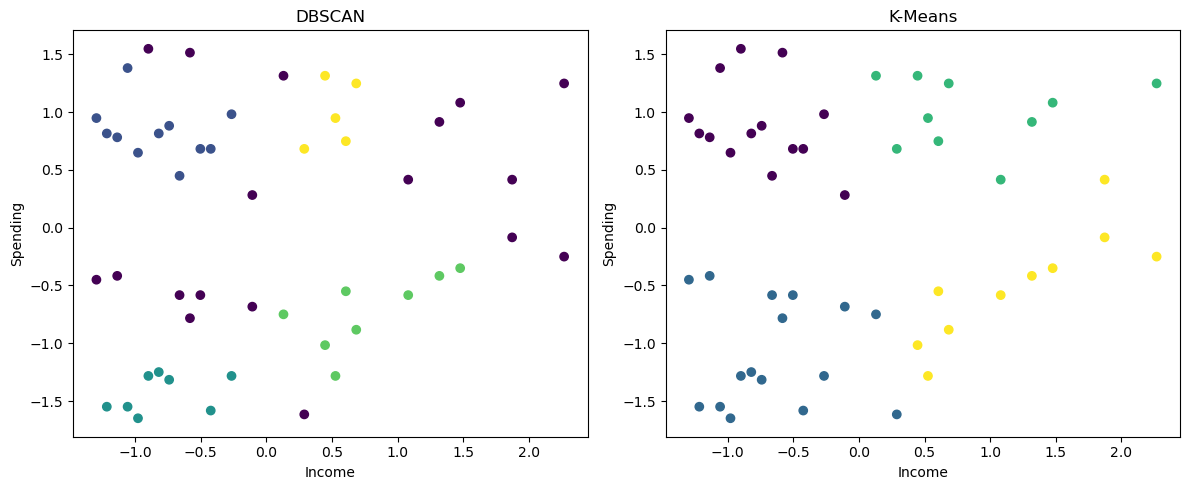

In [ ]:
from sklearn.cluster import KMeans

dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

k = len(set(db_labels)) - (1 if -1 in db_labels else 0)

if k < 2:
    k = 2

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

km_labels = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=db_labels
)

plt.title("DBSCAN")

plt.xlabel("Income")
plt.ylabel("Spending")

plt.subplot(1,2,2)

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=km_labels
)

plt.title("K-Means")

plt.xlabel("Income")
plt.ylabel("Spending")

plt.tight_layout()

plt.show()

5. Pick a dataset with non-spherical clusters (e.g., make_moons or make_circles from sklearn.datasets), and use DBSCAN to cluster the data. Identify and print the indices of all points labeled as noise (outliers).

Noise Point Indices:
[]


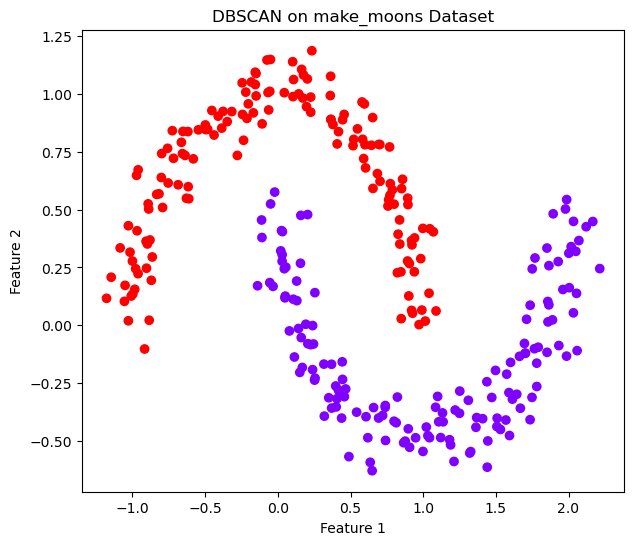

In [ ]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X, y = make_moons(
    n_samples=300,
    noise=0.08,
    random_state=42
)

dbscan = DBSCAN(
    eps=0.2,
    min_samples=5
)

labels = dbscan.fit_predict(X)

noise_indices = [i for i, label in enumerate(labels) if label == -1]

print("Noise Point Indices:")

print(noise_indices)

plt.figure(figsize=(7,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=labels,
    cmap="rainbow"
)

plt.title("DBSCAN on make_moons Dataset")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()